In [3]:


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.signal import hilbert
from pathlib import Path
from dataclasses import dataclass

from pylab import mpl
 
# 设置中文显示字体
mpl.rcParams["font.sans-serif"] = ["SimHei"]

In [9]:
#基础参数设置
CH="CH17"
fs = 64000              # 原始采样率 64kHz
f_motor = 20.0          # 电机输入频率 20Hz

In [7]:
#计算故障特征频率
# 1. 定义参数 (电机20Hz, 齿轮16/107)
fr = 20.0 * (16 / 107)  # 轴箱实际转频 ≈ 2.99 Hz

# 2. 计算故障频率 (基于 HRB 352213 系数)
f_bpfo = fr * 8.071     # 外圈 (LA2) ≈ 24.14 Hz
f_bsf  = fr * 3.164     # 滚动体 (LA3) ≈ 9.46 Hz (实际可能略低)
f_ftf  = fr * 0.425     # 保持架 (用于看边带) ≈ 1.27 Hz

# 3. 打印结果
print(f"转频: {fr:.2f}Hz | 外圈: {f_bpfo:.2f}Hz | 滚动体: {f_bsf:.2f}Hz | 保持架: {f_ftf:.2f}Hz")

转频: 2.99Hz | 外圈: 24.14Hz | 滚动体: 9.46Hz | 保持架: 1.27Hz


In [15]:
out_10=pd.read_csv('BJTU/正10负载/data_leftaxlebox_M0_G0_LA2_RA0_20Hz_+10kN.csv',usecols=['CH17'])

EmptyDataError: No columns to parse from file

In [10]:

#读取数据
#+10负载
out_10 = pd.read_csv('BJTU/正10负载/data_leftaxlebox_M0_G0_LA2_RA0_20Hz_+10kN.csv', usecols=['CH17'])[CH].values.astype(np.float32)
in_10 = pd.read_csv('BJTU/正10负载/data_leftaxlebox_M0_G0_LA1_RA0_20Hz_+10kN.csv', usecols=['CH17'])[CH].values.astype(np.float32)

bf_10 = pd.read_csv('BJTU/正10负载/data_leftaxlebox_M0_G0_LA3_RA0_20Hz_+10kN.csv', usecols=['CH17'])[CH].values.astype(np.float32)
mix_10       = pd.read_csv('BJTU/正10负载/data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_+10kN.csv', usecols=['CH17'])[CH].values.astype(np.float32)
#-10负载
out__10 = pd.read_csv('BJTU/负10负载/data_leftaxlebox_M0_G0_LA2_RA0_20Hz_-10kN.csv', usecols=['CH17'])[CH].values.astype(np.float32)
in__10 = pd.read_csv('BJTU/负10负载/data_leftaxlebox_M0_G0_LA1_RA0_20Hz_-10kN.csv', usecols=['CH17'])[CH].values.astype(np.float32)

bf__10 = pd.read_csv('BJTU/负10负载/data_leftaxlebox_M0_G0_LA3_RA0_20Hz_-10kN.csv', usecols=['CH17'])[CH].values.astype(np.float32)
mix__10       = pd.read_csv('BJTU/负10负载/data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_-10kN.csv', usecols=['CH17'])[CH].values.astype(np.float32)

#0kn负载
out_0 = pd.read_csv('BJTU/0负载/data_leftaxlebox_M0_G0_LA2_RA0_20Hz_0kN.csv', usecols=['CH17'])[CH].values.astype(np.float32)
in_0 = pd.read_csv('BJTU/0负载/data_leftaxlebox_M0_G0_LA1_RA0_20Hz_0kN.csv', usecols=['CH17'])[CH].values.astype(np.float32)
bf_0 = pd.read_csv('BJTU/0负载/data_leftaxlebox_M0_G0_LA3_RA0_20Hz_0kN.csv', usecols=['CH17'])[CH].values.astype(np.float32)
mix_0       = pd.read_csv('BJTU/0负载/data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_0kN.csv', usecols=['CH17'])[CH].values.astype(np.float32)


EmptyDataError: No columns to parse from file

In [11]:
from scipy import fftpack
def envelope_spectrum(data, fs, xlim=None, vline= None):
    '''
    fun: 绘制包络谱图
    param data: 输入数据，1维array
    param fs: 采样频率
    param xlim: 图片横坐标xlim，default = None
    param vline: 图片垂直线，default = None
    '''
    #----去直流分量----#
    #----做希尔伯特变换----#
    xt = data[:128000]
    ht = fftpack.hilbert(xt)
    at = np.sqrt(xt**2+ht**2)
    at = at - np.mean(at)# 获得解析信号at = sqrt(xt^2 + ht^2)
    am = np.fft.fft(at)         # 对解析信号at做fft变换获得幅值
    am = np.abs(am)             # 对幅值求绝对值（此时的绝对值很大）
    am = am/len(am)*2
    am = am[0: int(len(am)/2)]  # 取正频率幅值
    freq = np.fft.fftfreq(len(at), d=1 / fs)  # 获取fft频率，此时包括正频率和负频率
    freq = freq[0:int(len(freq)/2)]  # 获取正频率
    return freq, am

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_refined_envelope_ax(ax, freq, amp, motor_f, title="轴承故障诊断", xlim=100, fault_types=['BPFO', 'BSF']):
    """
    修改后的绘图函数，接收 ax 参数以支持多图布局
    """
    # 1. 自动计算 BJTU 理论频率
    fr = motor_f / (107/16)
    theory = {
        'BPFO': {'val': fr * 8.071,  'color': '#d62728', 'ls': '--', 'label': '外圈 BPFO'},
        'BPFI': {'val': fr * 10.929, 'color': '#ff7f0e', 'ls': ':',  'label': '内圈 BPFI'},
        'BSF':  {'val': fr * 3.164,  'color': '#2ca02c', 'ls': '-.', 'label': '滚动体 BSF'}
    }
    
    # 2. 在指定的 ax 上绘图
    ax.plot(freq, amp, color='#1f77b4', linewidth=1.2, label='包络幅值', zorder=3)
    ax.fill_between(freq, amp, color='#1f77b4', alpha=0.15, zorder=2)
    
    # 3. 自动添加故障标注线 (1倍频)
    for ft in fault_types:
        if ft in theory:
            info = theory[ft]
            ax.axvline(info['val'], color=info['color'], linestyle=info['ls'], 
                       linewidth=1.8, label=f"{info['label']} ({info['val']:.2f}Hz)", zorder=4)
            # 如果需要2倍频，取消下面一行的注释
            ax.axvline(info['val']*2, color=info['color'], linestyle=info['ls'], linewidth=1.2, alpha=0.6, zorder=4)
    
    # 标注转频 fr
    ax.axvline(fr, color='#7f7f7f', linestyle='--', alpha=0.5, label=f'车轴转频 fr ({fr:.2f}Hz)', zorder=1)

    # 4. 细节美化
    ax.set_title(title, fontsize=13, pad=15, fontweight='bold')
    ax.set_xlabel('频率 Frequency (Hz)', fontsize=10)
    ax.set_ylabel('幅值 Amplitude', fontsize=10)
    ax.set_xlim(0, xlim)
    
    # 动态调整Y轴 (避开0Hz直流分量)
    valid_amp = amp[freq > 1]
    if len(valid_amp) > 0:
        ax.set_ylim(0, np.max(valid_amp) * 1.6) 
    
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='upper right', frameon=True, shadow=False, fontsize=8)

# ==========================================
# 调用方法：左右呈现
# ==========================================



NameError: name 'in_0' is not defined

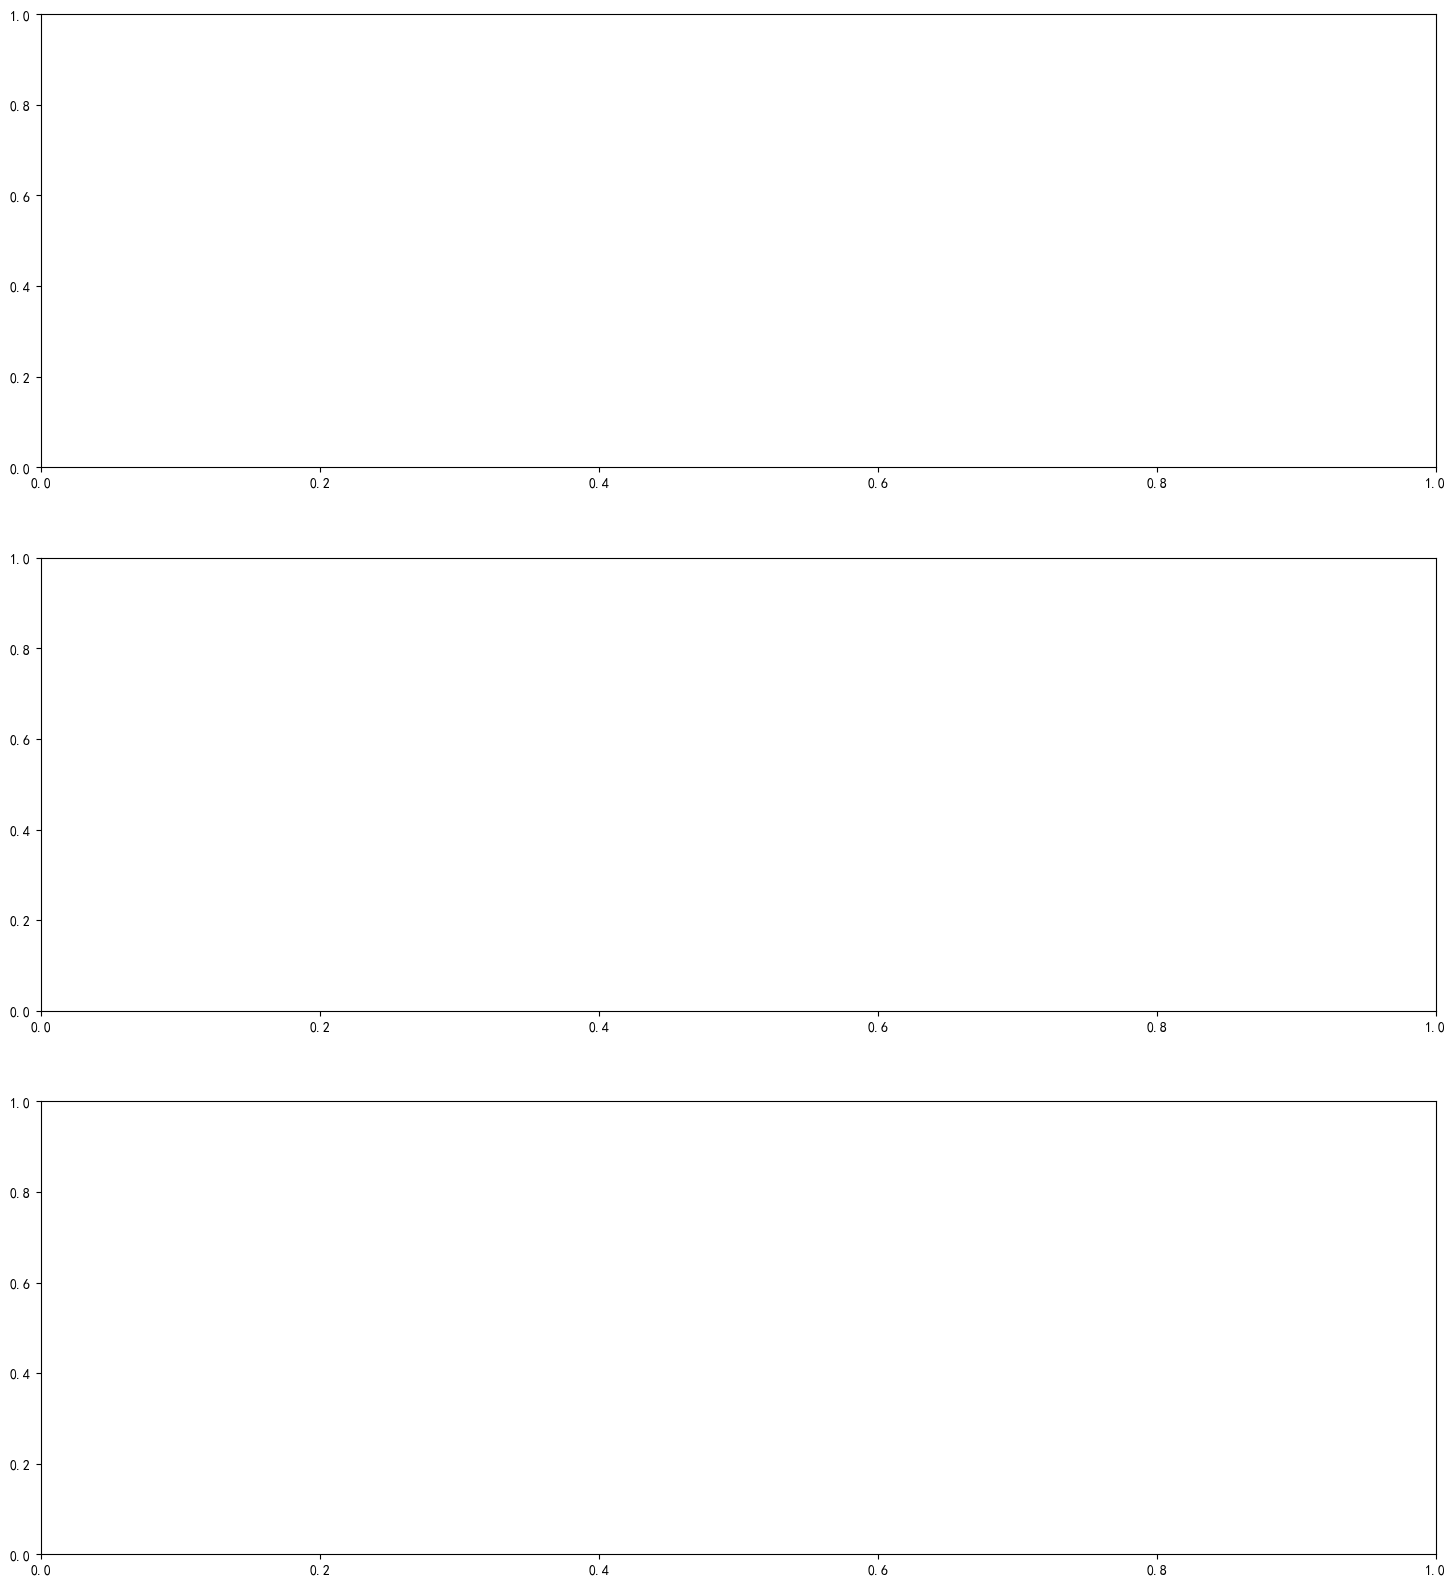

In [13]:
# 1. 创建 1行2列 的画布
fig, (ax1, ax2,ax3) = plt.subplots(3, 1, figsize=(18, 20), dpi=100)

# 2. 分别调用函数画图
# 处理 0 负载数据
freq0, amp0 = envelope_spectrum(in_0, 64000)
plot_refined_envelope_ax(ax1, freq0, amp0, motor_f=20, 
                         title="LA1 内圈故障诊断 (0kN 负载)", fault_types=['BPFI'])

# 处理 +10 负载数据
freq10, amp10 = envelope_spectrum(in_10, 64000)
plot_refined_envelope_ax(ax2, freq10, amp10, motor_f=20, 
                         title="LA1 内圈故障诊断 (+10kN 负载)", fault_types=['BPFI'])
# 处理 -10 负载数据
freq10, amp10 = envelope_spectrum(in__10, 64000)
plot_refined_envelope_ax(ax3, freq10, amp10, motor_f=20, 
                         title="LA1 内圈故障诊断 (-10kN 负载)", fault_types=['BPFI'])

# 3. 调整整体布局并显示
plt.tight_layout()
plt.show()

In [ ]:
# 1. 创建 1行2列 的画布
fig, (ax1, ax2,ax3) = plt.subplots(3, 1, figsize=(18, 20), dpi=100)

# 2. 分别调用函数画图
# 处理 0 负载数据
freq0, amp0 = envelope_spectrum(out_0, 64000)
plot_refined_envelope_ax(ax1, freq0, amp0, motor_f=20, 
                         title="LA2 外圈故障诊断 (0kN 负载)", fault_types=['BPFO'])

# 处理 +10 负载数据
freq10, amp10 = envelope_spectrum(out_10, 64000)
plot_refined_envelope_ax(ax2, freq10, amp10, motor_f=20, 
                         title="LA2 外圈故障诊断 (+10kN 负载)", fault_types=['BPFO'])
# 处理 -10 负载数据
freq10, amp10 = envelope_spectrum(out__10, 64000)
plot_refined_envelope_ax(ax3, freq10, amp10, motor_f=20, 
                         title="LA2 外圈故障诊断 (-10kN 负载)", fault_types=['BPFO'])
# 3. 调整整体布局并显示
plt.tight_layout()
plt.show()

In [ ]:
# 1. 创建 1行2列 的画布
fig, (ax1, ax2,ax3) = plt.subplots(3, 1, figsize=(18, 20), dpi=100)

# 2. 分别调用函数画图
# 处理 0 负载数据
freq0, amp0 = envelope_spectrum(bf_0, 64000)
plot_refined_envelope_ax(ax1, freq0, amp0, motor_f=20, 
                         title="LA3 滚动体故障诊断 (0kN 负载)", fault_types=['BSF'])

# 处理 10 负载数据
freq10, amp10 = envelope_spectrum(bf_10, 64000)
plot_refined_envelope_ax(ax2, freq10, amp10, motor_f=20, 
                         title="LA3 滚动体故障诊断 (+10kN 负载)", fault_types=['BSF'])
# 处理 10 负载数据
freq10, amp10 = envelope_spectrum(bf_10, 64000)
plot_refined_envelope_ax(ax3, freq10, amp10, motor_f=20, 
                         title="LA3 滚动体故障诊断 (-10kN 负载)", fault_types=['BSF'])
# 3. 调整整体布局并显示
plt.tight_layout()
plt.show()

In [ ]:
# 1. 创建 1行2列 的画布
fig, (ax1, ax2,ax3) = plt.subplots(3, 1, figsize=(18, 20), dpi=100)

# 2. 分别调用函数画图
# 处理 0 负载数据
freq0, amp0 = envelope_spectrum(mix_0, 64000)
plot_refined_envelope_ax(ax1, freq0, amp0, motor_f=20, 
                         title="LA2+LA3 复合故障诊断(外圈、滚动体) (0kN 负载)", fault_types=['BPFO','BSF'])

# 处理 10 负载数据
freq10, amp10 = envelope_spectrum(mix_10, 64000)
plot_refined_envelope_ax(ax2, freq10, amp10, motor_f=20, 
                         title="LA2+LA3 复合故障诊断(外圈、滚动体) (+10kN 负载)", fault_types=['BPFO','BSF'])
# 处理 10 负载数据
freq10, amp10 = envelope_spectrum(mix__10, 64000)
plot_refined_envelope_ax(ax3, freq10, amp10, motor_f=20, 
                         title="LA2+LA3 复合故障诊断(外圈、滚动体) (-10kN 负载)", fault_types=['BPFO','BSF'])
# 3. 调整整体布局并显示
plt.tight_layout()
plt.show()